# scipy.stats — distributions, tests, correlation, regression

Every section starts with a tiny example you can check by hand, then shows the same thing
on the real hourly power data. Only numpy / pandas / scipy (no statsmodels).

**What's in here**
- distribution objects: `pdf`, `cdf`, `ppf`, `rvs`, `fit`
- describing a sample: mean, sd, skew, kurtosis
- normality tests and why they always reject at large n
- two-sample tests: t-test, Mann-Whitney, KS
- correlation with a p-value (Pearson, Spearman)
- simple regression three ways
- confidence intervals by formula and by bootstrap
- autocorrelation by hand and the effective sample size
- multiple testing

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

pd.set_option("display.width", 120)
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42)

## 1. Distribution objects

`stats.norm` is the normal distribution. `loc` is the mean, `scale` the standard deviation.
Four methods matter:

- `pdf(x)` density at x
- `cdf(x)` probability of a value ≤ x
- `ppf(q)` the inverse: the x such that P(X ≤ x) = q
- `rvs(size)` random draws

In [2]:
z = stats.norm(loc=0, scale=1)         # a "frozen" standard normal
print("pdf(0)     :", z.pdf(0))
print("cdf(0)     :", z.cdf(0))        # half the mass is below 0
print("cdf(1.96)  :", z.cdf(1.96))     # 97.5% is below 1.96
print("ppf(0.975) :", z.ppf(0.975))    # the inverse of the line above

pdf(0)     : 0.3989422804014327
cdf(0)     : 0.5
cdf(1.96)  : 0.9750021048517795
ppf(0.975) : 1.959963984540054


`cdf(1.96) = 0.975` and `ppf(0.975) = 1.96` are the same fact read in two directions.
That is where the "1.96" in a 95% confidence interval comes from.

In [3]:
draws = z.rvs(size=5, random_state=rng)
draws

array([ 0.3047, -1.04  ,  0.7505,  0.9406, -1.951 ])

`loc` and `scale` shift and stretch. A normal with mean 100 and sd 15:

In [4]:
x = stats.norm(loc=100, scale=15)
print("P(X <= 130) :", x.cdf(130))
print("95th pct    :", x.ppf(0.95))

P(X <= 130) : 0.9772498680518208
95th pct    : 124.67280440427209


Student-t has fatter tails than the normal. Compare the probability of a value beyond 3:

In [5]:
print("normal   P(|X| > 3):", 2 * stats.norm.sf(3))
print("t(df=3)  P(|X| > 3):", 2 * stats.t.sf(3, df=3))

normal   P(|X| > 3): 0.0026997960632601866
t(df=3)  P(|X| > 3): 0.05766888562243731


`sf` is the survival function, 1 − cdf. The t with 3 degrees of freedom puts about 20×
more mass beyond 3 than the normal. Price changes look like that.

`fit` estimates the parameters from data. Draw 1000 values from a known normal and recover them:

In [6]:
sample = stats.norm(loc=5, scale=2).rvs(1000, random_state=rng)
mu_hat, sd_hat = stats.norm.fit(sample)
print("true mu, sd     : 5 2")
print("fitted mu, sd   :", round(mu_hat, 3), round(sd_hat, 3))

true mu, sd     : 5 2
fitted mu, sd   : 4.943 1.972


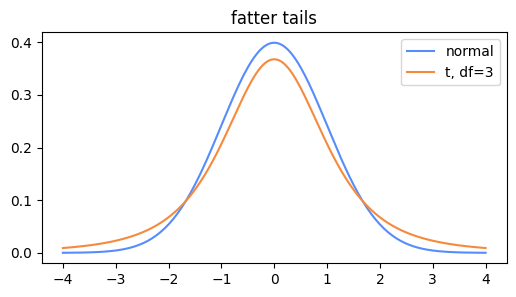

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline
xs = np.linspace(-4, 4, 200)
plt.figure(figsize=(6, 3))
plt.plot(xs, stats.norm.pdf(xs), label="normal")
plt.plot(xs, stats.t.pdf(xs, df=3), label="t, df=3")
plt.legend(); plt.title("fatter tails"); plt.show()

## 2. Describing a sample

Five numbers. Compute the descriptive statistics by hand, then with `stats.describe`.

In [8]:
x = np.array([2.0, 4.0, 4.0, 5.0, 10.0])
print("n     :", len(x))
print("mean  :", x.mean())
print("sd    :", x.std(ddof=1))          # divide by n-1 (sample sd)
print("min   :", x.min(), " max:", x.max())

n     : 5
mean  : 5.0
sd    : 3.0
min   : 2.0  max: 10.0


In [9]:
stats.describe(x)

DescribeResult(nobs=5, minmax=(2.0, 10.0), mean=5.0, variance=9.0, skewness=0.9938079899999065, kurtosis=-0.2685185185185186)

`variance` is sd² = 3.1623² = 10. `skewness` > 0 because the 10 pulls the right tail out.
`kurtosis` here is *excess* kurtosis (normal = 0).

Skew and kurtosis on their own:

In [10]:
print("skew     :", stats.skew(x))
print("kurtosis :", stats.kurtosis(x))     # excess; 0 for a normal

skew     : 0.9938079899999065
kurtosis : -0.2685185185185186


On real data: hourly price changes. Kurtosis far above 0 = fat tails (spikes).

In [11]:
df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"])
dprice = df["price_eur_mwh"].diff().dropna()
print("n        :", len(dprice))
print("mean     :", round(dprice.mean(), 3))
print("sd       :", round(dprice.std(), 3))
print("skew     :", round(stats.skew(dprice), 3))
print("kurtosis :", round(stats.kurtosis(dprice), 3))

n        : 17519
mean     : -0.001
sd       : 24.186
skew     : -0.13
kurtosis : 22.731


## 3. Normality tests

`shapiro` and `jarque_bera` test H0: "the data are normal". A small p-value rejects.
Start with 30 draws that really are normal:

In [12]:
normal_30 = stats.norm.rvs(size=30, random_state=rng)
stat, p = stats.shapiro(normal_30)
print("shapiro statistic:", round(stat, 4), " p-value:", round(p, 4))

shapiro statistic: 0.9524  p-value: 0.1959


p is large: no evidence against normality, as expected.

**Pitfall:** at large n every real dataset rejects, because nothing real is exactly normal.
Add a tiny deviation and grow n:

In [13]:
for n in [50, 500, 5000, 50000]:
    slightly_off = stats.t.rvs(df=30, size=n, random_state=rng)   # almost normal
    stat, p = stats.jarque_bera(slightly_off)
    print(f"n={n:6d}   p={p:.4f}")

n=    50   p=0.2776
n=   500   p=0.2104
n=  5000   p=0.0003
n= 50000   p=0.0000


The same distribution, a p-value that only depends on n. Use the test to describe, not to decide:
look at skew/kurtosis and a plot instead.

## 4. Two-sample tests

Two small groups. Is the mean of B higher than the mean of A?

In [14]:
a = np.array([10.0, 12.0, 11.0, 13.0, 9.0])
b = np.array([14.0, 15.0, 13.0, 16.0, 12.0])
print("mean a:", a.mean(), " mean b:", b.mean(), " difference:", b.mean() - a.mean())

mean a: 11.0  mean b: 14.0  difference: 3.0


The t statistic by hand: difference divided by its standard error.

In [15]:
se_a = a.std(ddof=1) / np.sqrt(len(a))
se_b = b.std(ddof=1) / np.sqrt(len(b))
se_diff = np.sqrt(se_a**2 + se_b**2)
t_by_hand = (b.mean() - a.mean()) / se_diff
print("se_a     :", round(se_a, 4))
print("se_b     :", round(se_b, 4))
print("se_diff  :", round(se_diff, 4))
print("t        :", round(t_by_hand, 4))

se_a     : 0.7071
se_b     : 0.7071
se_diff  : 1.0
t        : 3.0


In [16]:
stats.ttest_ind(b, a, equal_var=False)       # Welch's t-test, same t

TtestResult(statistic=3.0, pvalue=0.017071681233782634, df=8.0)

Same t as by hand. p ≈ 0.02: a difference this large would happen about 2% of the time if
both groups had the same mean.

Mann-Whitney uses ranks instead of values (robust to outliers); KS compares whole distributions.

In [17]:
print(stats.mannwhitneyu(b, a))
print(stats.ks_2samp(b, a))

MannwhitneyuResult(statistic=23.0, pvalue=0.0355788332395941)
KstestResult(statistic=0.6, pvalue=0.35714285714285715, statistic_location=12.0, statistic_sign=-1)


On real data: is weekend consumption different from weekday?
Use **daily** means as the unit, not hourly rows (hours within a day are not independent).

In [18]:
daily = df.set_index("time")["consumption_mwh"].resample("D").mean()
weekend = daily[daily.index.dayofweek >= 5]
weekday = daily[daily.index.dayofweek < 5]
print("weekday days:", len(weekday), " mean:", round(weekday.mean(), 0))
print("weekend days:", len(weekend), " mean:", round(weekend.mean(), 0))
print(stats.ttest_ind(weekend, weekday, equal_var=False))

weekday days: 520  mean: 29914.0
weekend days: 210  mean: 27832.0
TtestResult(statistic=-12.836612548018103, pvalue=8.222261706395646e-32, df=398.8840452375371)


**Interview check:** "Why not run the t-test on the 17,520 hourly rows?" Because consecutive
hours are nearly copies of each other; the test would think it has 17,520 independent
observations and the p-value would be absurdly small. Aggregate to the level where
observations are roughly independent.

## 5. Correlation with a p-value

Five (x, y) pairs. Pearson correlation by hand, then `stats.pearsonr`.

In [19]:
x = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y = np.array([2.0, 4.0, 5.0, 4.0, 5.0])
xc = x - x.mean()
yc = y - y.mean()
r_by_hand = (xc * yc).sum() / np.sqrt((xc**2).sum() * (yc**2).sum())
print("x centred:", xc)
print("y centred:", yc)
print("r        :", round(r_by_hand, 4))

x centred: [-2. -1.  0.  1.  2.]
y centred: [-2.  0.  1.  0.  1.]
r        : 0.7746


In [20]:
r, p = stats.pearsonr(x, y)
print("pearsonr :", round(r, 4), " p-value:", round(p, 4))
print("pandas   :", round(pd.Series(x).corr(pd.Series(y)), 4), "(no p-value)")

pearsonr : 0.7746  p-value: 0.124
pandas   : 0.7746 (no p-value)


Spearman correlates the **ranks**. It ignores how big the values are, only their order,
so one outlier cannot dominate it.

In [21]:
x_out = np.array([1.0, 2.0, 3.0, 4.0, 50.0])     # one wild x
y_out = np.array([2.0, 4.0, 5.0, 4.0, 5.0])
print("pearson  :", round(stats.pearsonr(x_out, y_out)[0], 4))
print("spearman :", round(stats.spearmanr(x_out, y_out)[0], 4))

pearson  : 0.4894
spearman : 0.7379


On real data: temperature vs consumption, hourly.

In [22]:
r, p = stats.pearsonr(df["temp_c"], df["consumption_mwh"])
print("r:", round(r, 4), " p:", p)

r: -0.2208  p: 1.7071375032331722e-192


**Pitfall:** p = 0 is meaningless here for the same reason as before: 17,520 autocorrelated
hours are not 17,520 independent observations. Section 8 shows how to correct n.

## 6. Simple regression three ways

Four points that lie almost on y = 2x + 1.

In [23]:

y = np.array([1.1, 2.9, 5.2, 6.8])

In [24]:
res = stats.linregress(x, y)
print("slope     :", round(res.slope, 4))
print("intercept :", round(res.intercept, 4))
print("r         :", round(res.rvalue, 4))
print("p (slope) :", round(res.pvalue, 4))
print("stderr    :", round(res.stderr, 4))

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 5 and the array at index 1 has size 4

In [ ]:
slope, intercept = np.polyfit(x, y, deg=1)
print("polyfit   :", round(slope, 4), round(intercept, 4))

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(x.reshape(-1, 1), y)
print("sklearn   :", round(model.coef_[0], 4), round(model.intercept_, 4))

Three identical answers. Only `linregress` gives the standard error and p-value.
`x.reshape(-1, 1)` is needed because sklearn wants a 2-D feature matrix (rows × columns).

In [26]:
x = np.array([0.0, 1.0, 2.0, 3.0])
x.reshape(-1, 2)

array([[0., 1.],
       [2., 3.]])

## 7. Confidence intervals

One sample of 5. A 95% CI for the mean, step by step.

In [ ]:
x = np.array([10.0, 12.0, 11.0, 13.0, 9.0])
n = len(x)
mean = x.mean()
sd = x.std(ddof=1)
se = sd / np.sqrt(n)
t_crit = stats.t.ppf(0.975, df=n - 1)       # t, not 1.96, because n is small
print("mean   :", mean)
print("sd     :", round(sd, 4))
print("se     :", round(se, 4))
print("t crit :", round(t_crit, 4))
print("CI     :", round(mean - t_crit * se, 3), "to", round(mean + t_crit * se, 3))

In [ ]:
stats.t.interval(0.95, df=n - 1, loc=mean, scale=se)      # same interval

The bootstrap does the same job without a formula: resample the 5 values with replacement,
recompute the mean, repeat. Three resamples first:

In [ ]:
for i in range(3):
    resample = rng.choice(x, size=n, replace=True)
    print(resample, " mean:", resample.mean())

In [ ]:
boot_means = np.empty(2000)
for i in range(2000):
    boot_means[i] = rng.choice(x, size=n, replace=True).mean()
print("bootstrap se :", round(boot_means.std(), 4), " (formula se:", round(se, 4), ")")
print("bootstrap CI :", np.percentile(boot_means, [2.5, 97.5]))

In [ ]:
stats.bootstrap((x,), np.mean, n_resamples=2000, random_state=rng).confidence_interval

## 8. Autocorrelation by hand

A series of 6 values. Lag-1 autocorrelation = correlation between the series and itself
shifted by one.

In [27]:
s = pd.Series([1.0, 2.0, 3.0, 2.0, 1.0, 2.0])
pd.DataFrame({"s": s, "s.shift(1)": s.shift(1)})

,s,s.shift(1)
0,1.0,NaN
1,2.0,1.0
2,3.0,2.0
3,2.0,3.0
4,1.0,2.0
5,2.0,1.0


In [28]:
rho1 = s.corr(s.shift(1))          # pandas drops the NaN pair
print("lag-1 autocorrelation:", round(rho1, 4))
print("s.autocorr(1)        :", round(s.autocorr(1), 4))

lag-1 autocorrelation: 0.0
s.autocorr(1)        : 0.0


On real data the lag-1 autocorrelation of hourly consumption is close to 1.
When observations are that dependent, the *effective* number of independent observations is
roughly n · (1 − ρ) / (1 + ρ).

In [29]:
cons = df["consumption_mwh"]
rho = cons.autocorr(1)
n = len(cons)
n_eff = n * (1 - rho) / (1 + rho)
print("rho     :", round(rho, 4))
print("n       :", n)
print("n_eff   :", round(n_eff))

rho     : 0.935
n       : 17520
n_eff   : 588


**Interview check:** "Is r = 0.4 significant on 17,520 hours?" With n_eff a few hundred
instead of 17,520, the standard error of r is about 1/√n_eff, roughly 10× larger than the
naive one. Recompute the t statistic with n_eff before answering.

In [ ]:
r = stats.pearsonr(df["temp_c"], df["consumption_mwh"])[0]
t_naive = r * np.sqrt((n - 2) / (1 - r**2))
t_eff = r * np.sqrt((n_eff - 2) / (1 - r**2))
print("r        :", round(r, 4))
print("t naive  :", round(t_naive, 1))
print("t n_eff  :", round(t_eff, 1))

## 9. Multiple testing

Test 10 random features against a random target. Each has a 5% chance of a "significant"
p-value by luck alone.

In [ ]:
target = rng.normal(size=100)
p_values = np.empty(10)
for j in range(10):
    feature = rng.normal(size=100)
    p_values[j] = stats.pearsonr(feature, target)[1]
print("p-values     :", p_values.round(3))
print("p < 0.05     :", (p_values < 0.05).sum(), "of 10")

Bonferroni: divide the threshold by the number of tests.

In [ ]:
threshold = 0.05 / 10
print("bonferroni threshold:", threshold)
print("still significant   :", (p_values < threshold).sum())

Benjamini–Hochberg is less strict: sort the p-values, compare the k-th smallest with k/m · 0.05.

In [ ]:
p_sorted = np.sort(p_values)
m = len(p_sorted)
for k in range(1, m + 1):
    print(f"k={k:2d}  p={p_sorted[k-1]:.3f}  threshold={k / m * 0.05:.3f}  pass={p_sorted[k-1] <= k / m * 0.05}")

In [ ]:
stats.false_discovery_control(p_values).round(3)        # BH-adjusted p-values

## Quick reference

| Task | Call |
|---|---|
| density / probability / quantile | `stats.norm(loc, scale).pdf(x)`, `.cdf(x)`, `.ppf(q)` |
| random draws | `stats.norm.rvs(size=n, random_state=rng)` |
| fit parameters | `stats.norm.fit(x)` |
| describe | `stats.describe(x)`, `stats.skew`, `stats.kurtosis` |
| normality (large n: always rejects) | `stats.shapiro`, `stats.jarque_bera` |
| two means | `stats.ttest_ind(a, b, equal_var=False)` |
| ranks / distributions | `stats.mannwhitneyu`, `stats.ks_2samp` |
| correlation with p | `stats.pearsonr`, `stats.spearmanr` |
| simple regression with se | `stats.linregress(x, y)` |
| CI for a mean | `stats.t.interval(0.95, df=n-1, loc=mean, scale=se)` |
| bootstrap CI | `stats.bootstrap((x,), np.mean)` |
| effective n | `n * (1 - rho) / (1 + rho)` |
| multiple tests | `stats.false_discovery_control(p)` |